In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [5]:
# Load dataset

df = pd.read_csv("../Data/BrentOilPrices.csv")
# First five rows

df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [6]:
df["Date"] = pd.to_datetime(df["Date"])
# Verify conversion

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[ns]
 1   Price   9011 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 140.9 KB


In [7]:
df.isnull().sum()
df.duplicated().sum()
df.describe()

,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958720,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


In [8]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())
df.set_index("Date", inplace=True)

Start Date: 1987-05-20 00:00:00
End Date: 2022-11-14 00:00:00


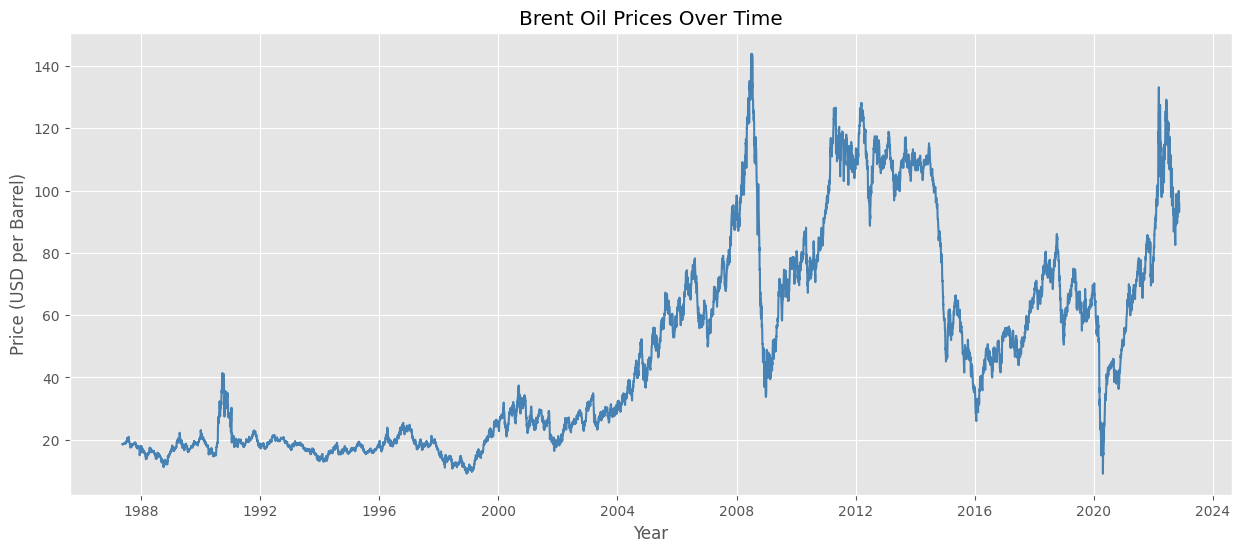

In [9]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df["Price"], color="steelblue")

plt.title("Brent Oil Prices Over Time")

plt.xlabel("Year")

plt.ylabel("Price (USD per Barrel)")

plt.show()

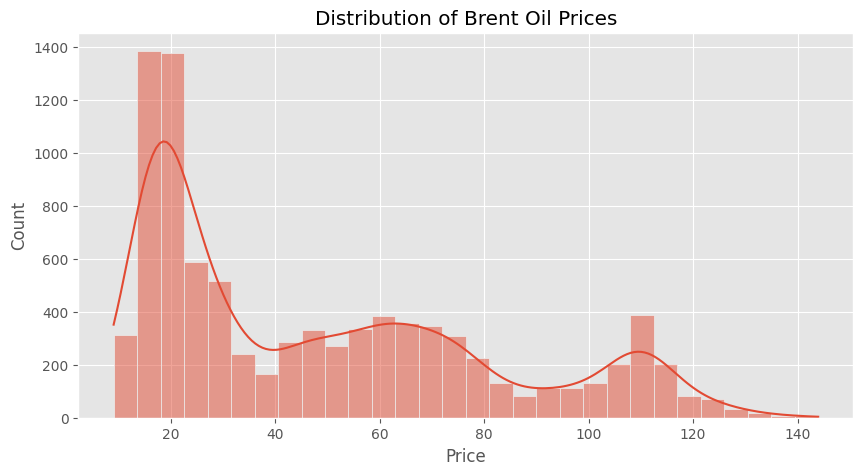

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(df["Price"], bins=30, kde=True)

plt.title("Distribution of Brent Oil Prices")

plt.show()

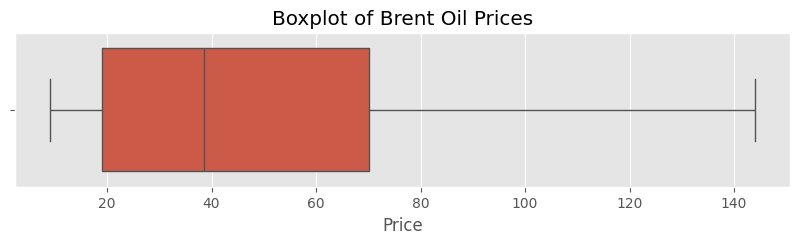

In [11]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Price"])

plt.title("Boxplot of Brent Oil Prices")

plt.show()

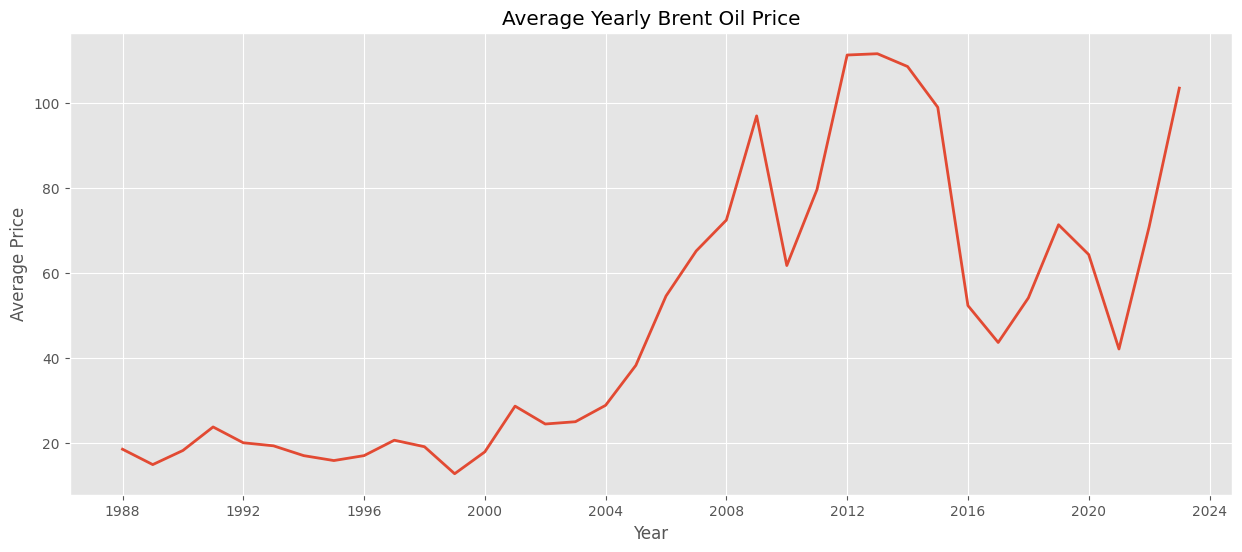

In [12]:
yearly_prices = df.resample("Y").mean()
plt.figure(figsize=(15,6))

plt.plot(yearly_prices.index,
         yearly_prices["Price"],
         linewidth=2)

plt.title("Average Yearly Brent Oil Price")

plt.xlabel("Year")

plt.ylabel("Average Price")

plt.show()

In [13]:
df.sort_values("Price", ascending=False).head(10)

,Price
Date,
2008-07-03,143.95
2008-07-11,143.68
2008-07-14,142.43
2008-07-02,141.24
2008-07-01,140.67
2008-07-07,139.62
2008-06-27,139.38
2008-06-30,138.40
2008-06-26,136.82


In [14]:
df.sort_values("Price").head(10)
monthly = df.resample("M").mean()

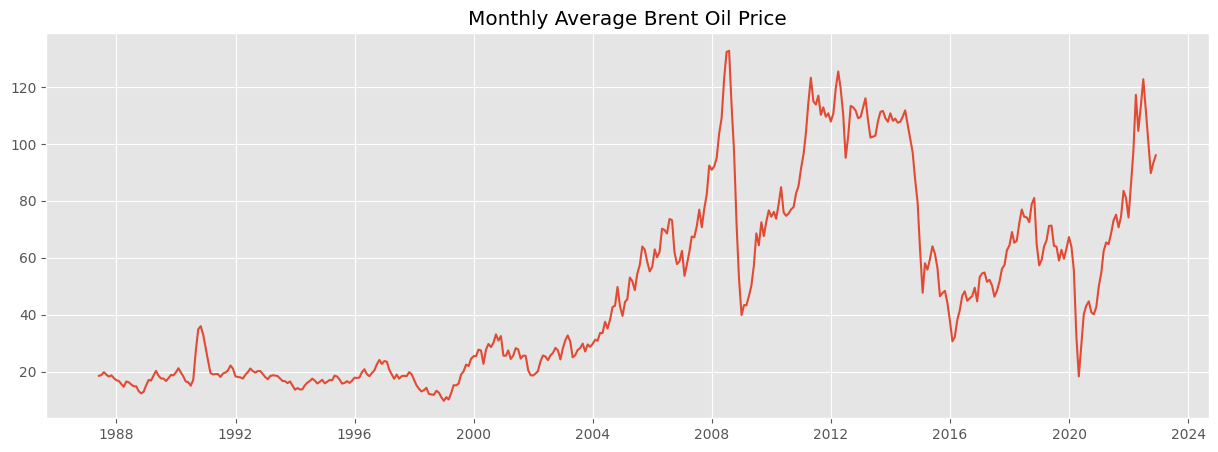

In [15]:
plt.figure(figsize=(15,5))

plt.plot(monthly.index,
         monthly["Price"])

plt.title("Monthly Average Brent Oil Price")

plt.show()

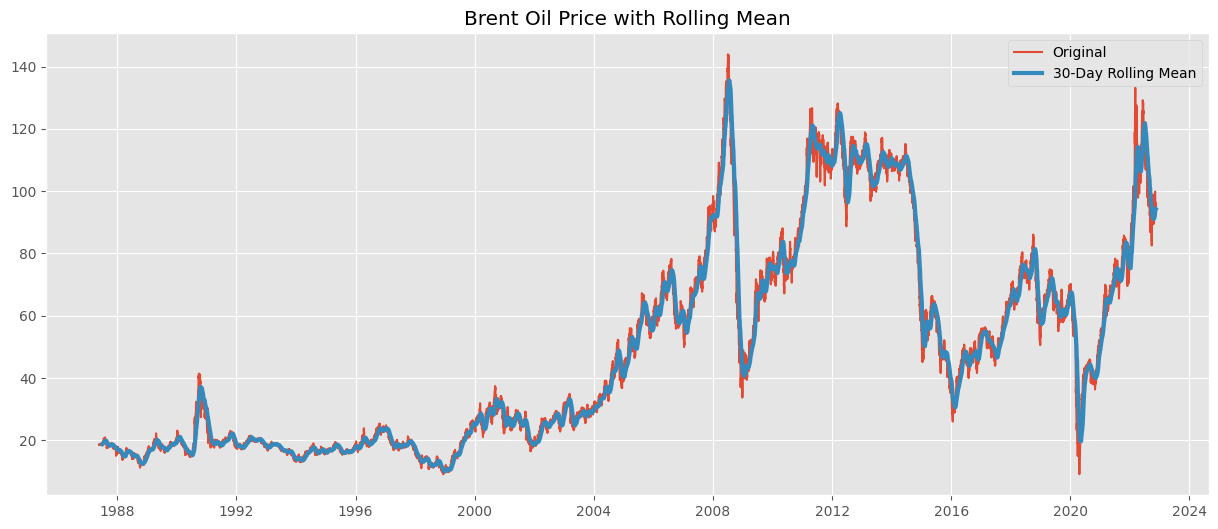

In [16]:
rolling_mean = df["Price"].rolling(30).mean()
plt.figure(figsize=(15,6))

plt.plot(df.index,
         df["Price"],
         label="Original")

plt.plot(df.index,
         rolling_mean,
         linewidth=3,
         label="30-Day Rolling Mean")

plt.legend()

plt.title("Brent Oil Price with Rolling Mean")

plt.show()

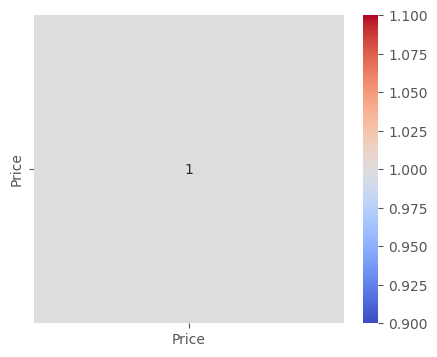

In [17]:
plt.figure(figsize=(5,4))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()